# Chrono Force & Spring Examples

이 노트북은 Project Chrono Phase2에서 다룬 **힘(Force)**, **스프링(Spring)**, **댐퍼(Damper)** 개념을 실험하기 위한 예제 노트북이다.

포함된 예제:

1. TSDA 기본 선형 스프링-댐퍼
2. TSDA + Custom ForceFunctor
3. RSDA 기본 회전 스프링-댐퍼
4. RSDA + Custom TorqueFunctor
5. 이론해와 시뮬레이션 비교 및 RMSE 계산

저장 추천 위치:

```text
lessons/phase2/Dohee/experiments/chrono_force_and_spring_examples.ipynb
```


## 0. 기본 import

먼저 Chrono, NumPy, Matplotlib을 불러온다.

> 만약 `ModuleNotFoundError: No module named 'pychrono'`가 나오면, 현재 Jupyter 커널이 Chrono가 설치된 conda 환경인지 확인해야 한다.


In [3]:
import pychrono as chrono
import numpy as np
import matplotlib.pyplot as plt

print("PyChrono import success")
print("Available chrono module:", chrono)

PyChrono import success
Available chrono module: <module 'pychrono' from 'c:\\Users\\lahee\\anaconda3\\envs\\chrono\\Lib\\site-packages\\pychrono\\__init__.py'>


---  

# Example 1. TSDA 기본 선형 스프링-댐퍼

## 목적

두 물체를 병진 방향 스프링-댐퍼로 연결하고, 물체가 진동하는 응답을 확인한다.

기본 힘 모델:

```text
F = -k x - c v
```

여기서,

- `k`: 스프링 강성
- `c`: 감쇠 계수
- `x`: 기준 길이로부터의 변위
- `v`: 상대 속도


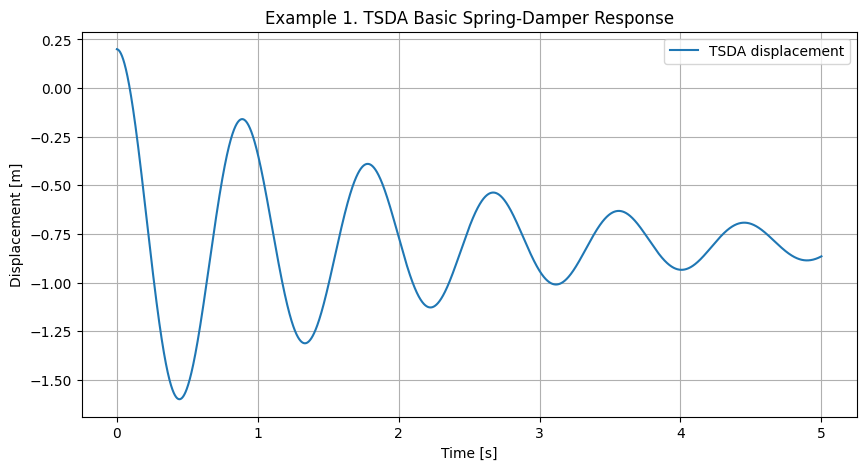

In [4]:
# =============================================================================
# Example 1. TSDA basic spring-damper
# =============================================================================

# Simulation parameters
mass = 1.0
k = 50.0
c = 1.0
rest_length = 1.0

initial_position = 1.2   # rest_length보다 0.2 m 늘어난 상태
dt = 0.001
t_end = 5.0

# Create Chrono system
system = chrono.ChSystemNSC()
system.SetGravitationalAcceleration(chrono.ChVector3d(0, 0, 0))

# Ground body
ground = chrono.ChBody()
ground.SetFixed(True)
ground.SetPos(chrono.ChVector3d(0, 0, 0))
system.Add(ground)

# Moving body
body = chrono.ChBody()
body.SetMass(mass)
body.SetInertiaXX(chrono.ChVector3d(1, 1, 1))
body.SetPos(chrono.ChVector3d(initial_position, 0, 0))
system.Add(body)

# TSDA
spring = chrono.ChLinkTSDA()

point_ground = chrono.ChVector3d(0, 0, 0)
point_body = chrono.ChVector3d(0, 0, 0)

spring.Initialize(ground, body, False, point_ground, point_body)
spring.SetRestLength(rest_length)
spring.SetSpringCoefficient(k)
spring.SetDampingCoefficient(c)

system.AddLink(spring)

# Simulation loop
time_data = []
x_data = []
v_data = []

while system.GetChTime() < t_end:
    system.DoStepDynamics(dt)

    time = system.GetChTime()
    pos = body.GetPos()
    vel = body.GetLinVel()

    x = pos.x - rest_length
    v = vel.x

    time_data.append(time)
    x_data.append(x)
    v_data.append(v)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(time_data, x_data, label="TSDA displacement")
plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.title("Example 1. TSDA Basic Spring-Damper Response")
plt.grid(True)
plt.legend()
plt.show()

## Example 1 해석

초기 위치를 `1.2 m`로 설정했고, 기준 길이 `rest_length = 1.0 m`이므로 초기 변위는 `0.2 m`이다.

스프링은 물체를 기준 길이 방향으로 되돌리려 하고, 댐퍼는 진동을 줄인다. 따라서 그래프는 시간이 지날수록 진폭이 감소하는 감쇠진동 형태가 되어야 한다.


---  

# Example 2. TSDA + Custom ForceFunctor

## 목적

Chrono 기본 스프링-댐퍼 모델 대신 사용자가 직접 힘 모델을 정의한다.

사용할 힘 모델:

```text
F = -k x - c v + F0 sin(ωt)
```

이 예제는 강제진동을 관찰하기 위한 코드이다.


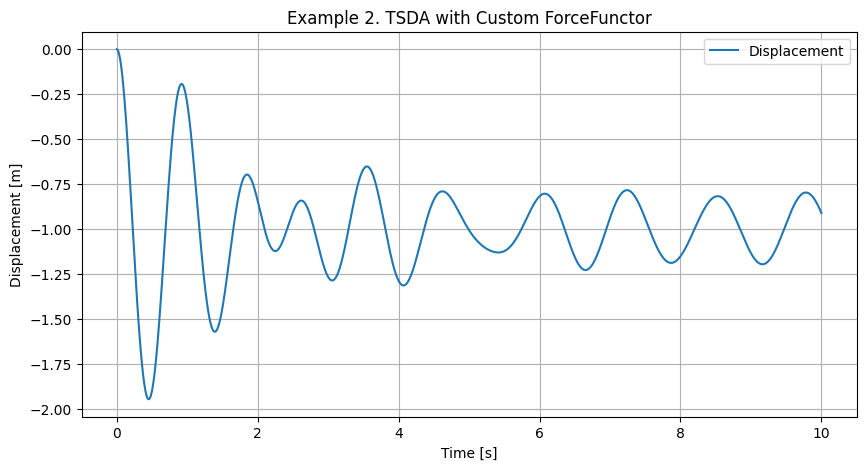

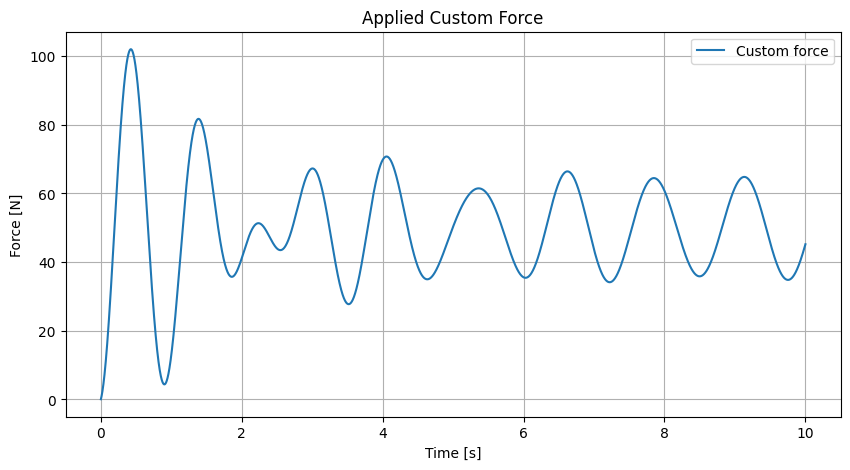

In [5]:
# =============================================================================
# Example 2. TSDA with Custom ForceFunctor
# =============================================================================

class CustomSpringForce(chrono.ForceFunctor):
    def __init__(self, k, c, F_amp, F_freq):
        super().__init__()
        self.k = k
        self.c = c
        self.F_amp = F_amp
        self.F_freq = F_freq

    def evaluate(self, time, rest_length, length, vel, link):
        x = length - rest_length

        F_spring = -self.k * x
        F_damper = -self.c * vel
        F_ext = self.F_amp * np.sin(self.F_freq * time)

        return F_spring + F_damper + F_ext


# Simulation parameters
mass = 1.0
k = 50.0
c = 1.0
rest_length = 1.0

F_amp = 5.0
F_freq = 5.0  # rad/s

initial_position = 1.0
dt = 0.001
t_end = 10.0

# Create Chrono system
system = chrono.ChSystemNSC()
system.SetGravitationalAcceleration(chrono.ChVector3d(0, 0, 0))

# Ground body
ground = chrono.ChBody()
ground.SetFixed(True)
ground.SetPos(chrono.ChVector3d(0, 0, 0))
system.Add(ground)

# Moving body
body = chrono.ChBody()
body.SetMass(mass)
body.SetInertiaXX(chrono.ChVector3d(1, 1, 1))
body.SetPos(chrono.ChVector3d(initial_position, 0, 0))
system.Add(body)

# TSDA with custom force
spring = chrono.ChLinkTSDA()
spring.Initialize(ground, body, False, chrono.ChVector3d(0, 0, 0), chrono.ChVector3d(0, 0, 0))
spring.SetRestLength(rest_length)

custom_force = CustomSpringForce(k, c, F_amp, F_freq)
spring.RegisterForceFunctor(custom_force)

system.AddLink(spring)

# Simulation loop
time_data = []
x_data = []
force_data = []

while system.GetChTime() < t_end:
    system.DoStepDynamics(dt)

    time = system.GetChTime()
    pos = body.GetPos()
    vel = body.GetLinVel()

    x = pos.x - rest_length
    v = vel.x
    F = -k * x - c * v + F_amp * np.sin(F_freq * time)

    time_data.append(time)
    x_data.append(x)
    force_data.append(F)

# Plot displacement
plt.figure(figsize=(10, 5))
plt.plot(time_data, x_data, label="Displacement")
plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.title("Example 2. TSDA with Custom ForceFunctor")
plt.grid(True)
plt.legend()
plt.show()

# Plot force
plt.figure(figsize=(10, 5))
plt.plot(time_data, force_data, label="Custom force")
plt.xlabel("Time [s]")
plt.ylabel("Force [N]")
plt.title("Applied Custom Force")
plt.grid(True)
plt.legend()
plt.show()

## Example 2 해석

`CustomSpringForce` 클래스는 `chrono.ForceFunctor`를 상속한다.

Chrono는 매 시간 스텝마다 `evaluate()` 함수를 호출해서 TSDA가 발생시킬 힘을 계산한다.

이 방식은 다음과 같은 경우에 유용하다.

```text
1. 시간에 따라 변하는 외력을 넣고 싶을 때
2. 비선형 스프링 모델을 만들고 싶을 때
3. 제어 입력이 포함된 액추에이터를 만들고 싶을 때
4. 실험 데이터 기반 힘 모델을 넣고 싶을 때
```


---  

# Example 3. RSDA 기본 회전 스프링-댐퍼

## 목적

두 물체 사이에 회전 방향 스프링-댐퍼를 연결한다.

기본 토크 모델:

```text
T = -kθ θ - cθ ω
```

여기서,

- `kθ`: 회전 스프링 강성
- `cθ`: 회전 감쇠 계수
- `θ`: 상대 회전각
- `ω`: 상대 각속도


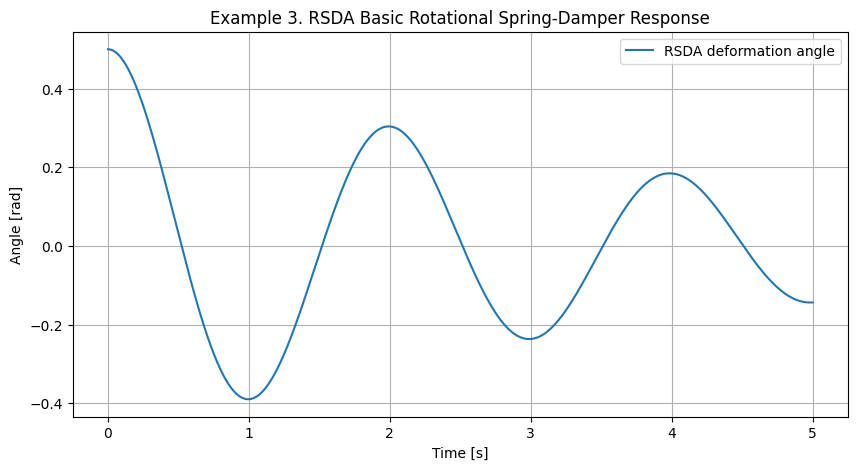

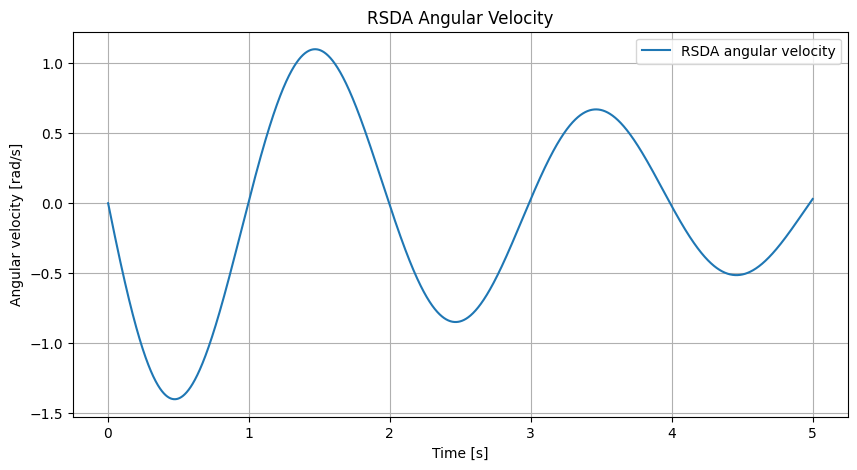

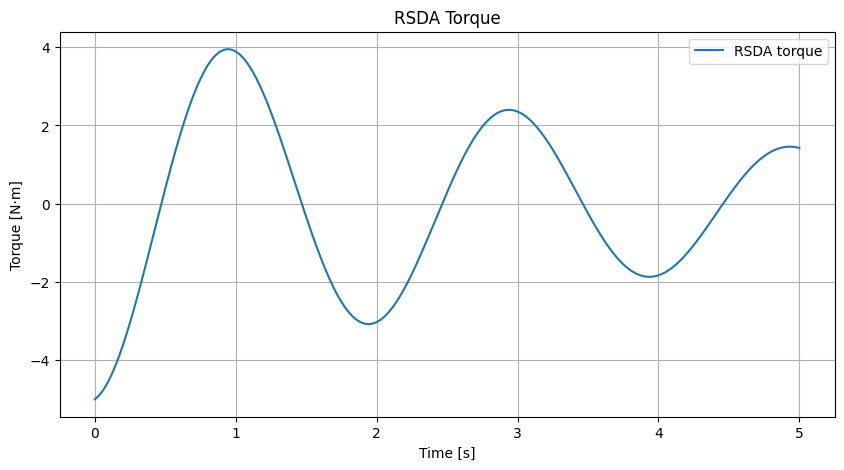

In [10]:
# =============================================================================
# Example 3. RSDA basic rotational spring-damper - corrected working version
# =============================================================================

# Simulation parameters
I = 1.0
k_theta = 10.0
c_theta = 0.5

initial_angle = 0.5  # rad
dt = 0.001
t_end = 5.0

# Create Chrono system
system = chrono.ChSystemNSC()
system.SetGravitationalAcceleration(chrono.ChVector3d(0, 0, 0))

# Ground body
ground = chrono.ChBody()
ground.SetFixed(True)
ground.SetPos(chrono.ChVector3d(0, 0, 0))
system.Add(ground)

# Rotating body
body = chrono.ChBody()
body.SetMass(1.0)
body.SetInertiaXX(chrono.ChVector3d(I, I, I))
body.SetPos(chrono.ChVector3d(0, 0, 0))

# Important:
# 처음에는 0 rad 상태로 둔다.
# 이 상태를 joint와 RSDA의 기준 상태로 초기화한다.
body.SetRot(chrono.QuatFromAngleZ(0.0))
body.SetAngVelLocal(chrono.ChVector3d(0, 0, 0))

system.Add(body)

# Joint frame
joint_frame = chrono.ChFramed(
    chrono.ChVector3d(0, 0, 0),
    chrono.QUNIT
)

# Revolute joint
# Z축 회전만 허용
joint = chrono.ChLinkLockRevolute()
joint.Initialize(ground, body, joint_frame)
system.AddLink(joint)

# RSDA
rsda = chrono.ChLinkRSDA()
rsda.Initialize(ground, body, joint_frame)

# 기준각을 0 rad로 명시
rsda.SetRestAngle(0.0)
rsda.SetSpringCoefficient(k_theta)
rsda.SetDampingCoefficient(c_theta)

system.AddLink(rsda)

# ------------------------------------------------------------
# 핵심 수정:
# joint와 RSDA를 초기화한 뒤에 body를 initial_angle만큼 회전시킨다.
# 그래야 RSDA가 이 각도를 deformation으로 인식한다.
# ------------------------------------------------------------
body.SetRot(chrono.QuatFromAngleZ(initial_angle))
body.SetAngVelLocal(chrono.ChVector3d(0, 0, 0))

# Simulation loop
time_data = []
theta_data = []
omega_data = []
torque_data = []

while system.GetChTime() < t_end:
    system.DoStepDynamics(dt)

    time = system.GetChTime()

    theta = rsda.GetDeformation()
    omega = rsda.GetVelocity()
    torque = rsda.GetTorque()

    time_data.append(time)
    theta_data.append(theta)
    omega_data.append(omega)
    torque_data.append(torque)

# Plot angle
plt.figure(figsize=(10, 5))
plt.plot(time_data, theta_data, label="RSDA deformation angle")
plt.xlabel("Time [s]")
plt.ylabel("Angle [rad]")
plt.title("Example 3. RSDA Basic Rotational Spring-Damper Response")
plt.grid(True)
plt.legend()
plt.show()

# Plot angular velocity
plt.figure(figsize=(10, 5))
plt.plot(time_data, omega_data, label="RSDA angular velocity")
plt.xlabel("Time [s]")
plt.ylabel("Angular velocity [rad/s]")
plt.title("RSDA Angular Velocity")
plt.grid(True)
plt.legend()
plt.show()

# Plot torque
plt.figure(figsize=(10, 5))
plt.plot(time_data, torque_data, label="RSDA torque")
plt.xlabel("Time [s]")
plt.ylabel("Torque [N·m]")
plt.title("RSDA Torque")
plt.grid(True)
plt.legend()
plt.show()

## Example 3 해석

RSDA는 회전 방향의 TSDA라고 생각하면 된다.

TSDA가 변위 `x`와 속도 `v`에 따라 힘 `F`를 만든다면, RSDA는 회전각 `θ`와 각속도 `ω`에 따라 토크 `T`를 만든다.

```text
TSDA: F = -k x - c v
RSDA: T = -kθ θ - cθ ω
```

로버 설계에서는 회전 조인트, 힌지, 서스펜션 암의 회전 탄성 등을 표현할 때 사용할 수 있다.


---  

# Example 4. RSDA + Custom TorqueFunctor

## 목적

RSDA의 토크 모델을 사용자가 직접 정의한다.

사용할 토크 모델:

```text
T = -kθ θ - cθ ω + T0 sin(ω_ext t)
```


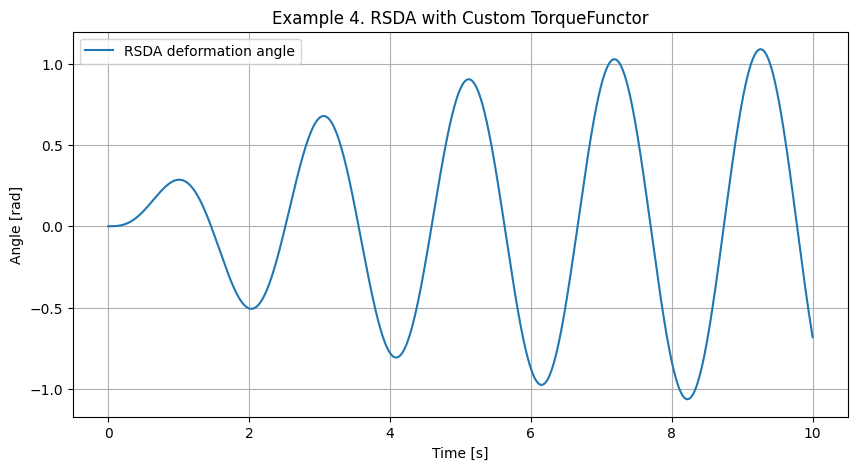

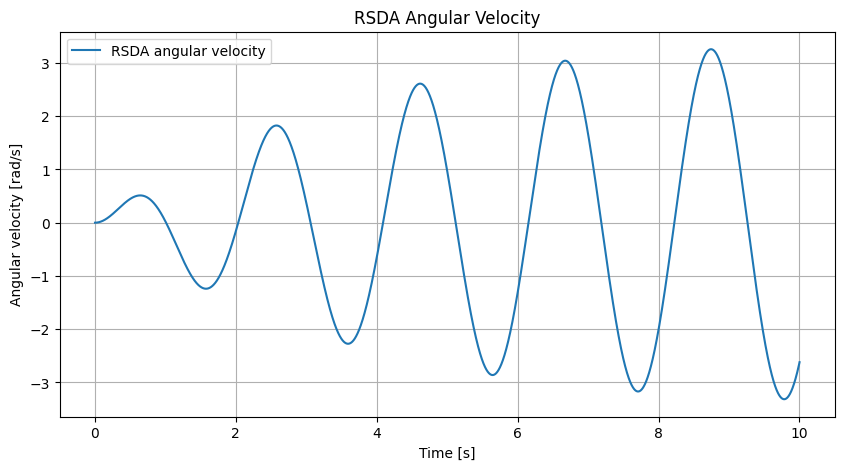

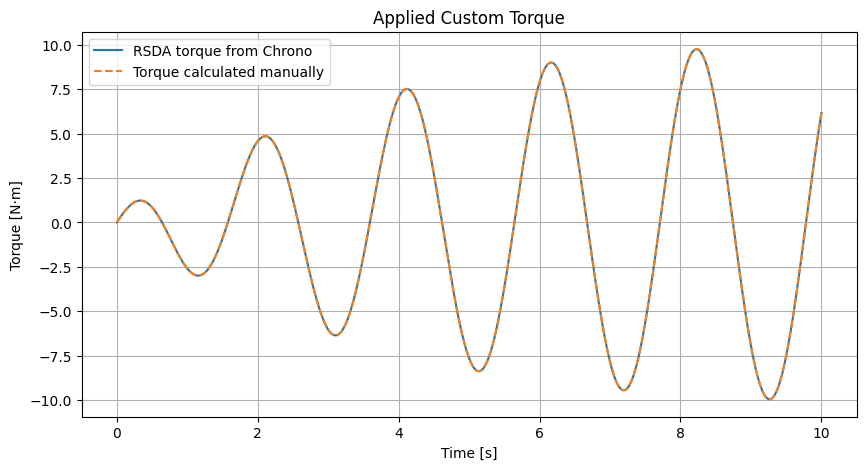

In [11]:
# =============================================================================
# Example 4. RSDA with Custom TorqueFunctor - corrected working version
# =============================================================================

class CustomRotationalTorque(chrono.TorqueFunctor):
    def __init__(self, k_theta, c_theta, T_amp, T_freq):
        super().__init__()
        self.k_theta = k_theta
        self.c_theta = c_theta
        self.T_amp = T_amp
        self.T_freq = T_freq

    def evaluate(self, time, rest_angle, angle, vel, link):
        # RSDA deformation angle
        theta = angle - rest_angle

        # Spring torque
        T_spring = -self.k_theta * theta

        # Damping torque
        T_damper = -self.c_theta * vel

        # External sinusoidal torque
        T_ext = self.T_amp * np.sin(self.T_freq * time)

        return T_spring + T_damper + T_ext


# =============================================================================
# Simulation parameters
# =============================================================================

I = 1.0
k_theta = 10.0
c_theta = 0.5

T_amp = 2.0
T_freq = 3.0  # rad/s

rest_angle = 0.0
initial_angle = 0.0

dt = 0.001
t_end = 10.0


# =============================================================================
# Create Chrono system
# =============================================================================

system = chrono.ChSystemNSC()
system.SetGravitationalAcceleration(chrono.ChVector3d(0, 0, 0))


# =============================================================================
# Ground body
# =============================================================================

ground = chrono.ChBody()
ground.SetFixed(True)
ground.SetPos(chrono.ChVector3d(0, 0, 0))
system.Add(ground)


# =============================================================================
# Rotating body
# =============================================================================

body = chrono.ChBody()
body.SetMass(1.0)
body.SetInertiaXX(chrono.ChVector3d(I, I, I))
body.SetPos(chrono.ChVector3d(0, 0, 0))

# 처음에는 기준 자세로 둔다.
# joint와 RSDA는 이 상태를 기준으로 초기화한다.
body.SetRot(chrono.QuatFromAngleZ(0.0))
body.SetAngVelLocal(chrono.ChVector3d(0, 0, 0))

system.Add(body)


# =============================================================================
# Revolute joint
# =============================================================================

joint_frame = chrono.ChFramed(
    chrono.ChVector3d(0, 0, 0),
    chrono.QUNIT
)

joint = chrono.ChLinkLockRevolute()
joint.Initialize(ground, body, joint_frame)
system.AddLink(joint)


# =============================================================================
# RSDA with custom torque
# =============================================================================

rsda = chrono.ChLinkRSDA()
rsda.Initialize(ground, body, joint_frame)

# 기준각 명시
rsda.SetRestAngle(rest_angle)

custom_torque = CustomRotationalTorque(
    k_theta=k_theta,
    c_theta=c_theta,
    T_amp=T_amp,
    T_freq=T_freq
)

rsda.RegisterTorqueFunctor(custom_torque)
system.AddLink(rsda)


# =============================================================================
# Apply initial angle after initializing joint and RSDA
# =============================================================================

body.SetRot(chrono.QuatFromAngleZ(initial_angle))
body.SetAngVelLocal(chrono.ChVector3d(0, 0, 0))


# =============================================================================
# Simulation loop
# =============================================================================

time_data = []
theta_data = []
omega_data = []
torque_data = []
torque_check_data = []

while system.GetChTime() < t_end:
    system.DoStepDynamics(dt)

    time = system.GetChTime()

    # RSDA 기준으로 읽는 값
    theta = rsda.GetDeformation()
    omega = rsda.GetVelocity()
    torque = rsda.GetTorque()

    # 직접 계산한 토크 확인용
    torque_check = (
        -k_theta * theta
        - c_theta * omega
        + T_amp * np.sin(T_freq * time)
    )

    time_data.append(time)
    theta_data.append(theta)
    omega_data.append(omega)
    torque_data.append(torque)
    torque_check_data.append(torque_check)


# =============================================================================
# Plot angle
# =============================================================================

plt.figure(figsize=(10, 5))
plt.plot(time_data, theta_data, label="RSDA deformation angle")
plt.xlabel("Time [s]")
plt.ylabel("Angle [rad]")
plt.title("Example 4. RSDA with Custom TorqueFunctor")
plt.grid(True)
plt.legend()
plt.show()


# =============================================================================
# Plot angular velocity
# =============================================================================

plt.figure(figsize=(10, 5))
plt.plot(time_data, omega_data, label="RSDA angular velocity")
plt.xlabel("Time [s]")
plt.ylabel("Angular velocity [rad/s]")
plt.title("RSDA Angular Velocity")
plt.grid(True)
plt.legend()
plt.show()


# =============================================================================
# Plot torque
# =============================================================================

plt.figure(figsize=(10, 5))
plt.plot(time_data, torque_data, label="RSDA torque from Chrono")
plt.plot(time_data, torque_check_data, "--", label="Torque calculated manually")
plt.xlabel("Time [s]")
plt.ylabel("Torque [N·m]")
plt.title("Applied Custom Torque")
plt.grid(True)
plt.legend()
plt.show()

## Example 4 해석

`CustomRotationalTorque`는 `chrono.TorqueFunctor`를 상속한다.

`evaluate()` 함수에서 현재 시간, 상대 각도, 상대 각속도를 이용해 토크를 계산한다.

TSDA에서 `ForceFunctor`가 힘을 반환했다면, RSDA에서는 `TorqueFunctor`가 토크를 반환한다.


---  

# Example 5. 이론해와 TSDA 시뮬레이션 비교

## 목적

TSDA 시뮬레이션 결과가 이론적인 질량-스프링-댐퍼 응답과 일치하는지 확인한다.

자유진동 운동방정식:

```text
m x'' + c x' + k x = 0
```

부족감쇠 조건에서 이론해는 다음 형태를 가진다.

```text
x(t) = exp(-ζω_n t) [x0 cos(ω_d t) + ((v0 + ζω_n x0) / ω_d) sin(ω_d t)]
```


Natural frequency omega_n      = 7.071068 rad/s
Damping ratio zeta             = 0.070711
Damped natural frequency omega_d = 7.053368 rad/s
RMSE                           = 0.0001728920 m
Max error                      = 0.0003510065 m
Relative max error             = 0.175503 %


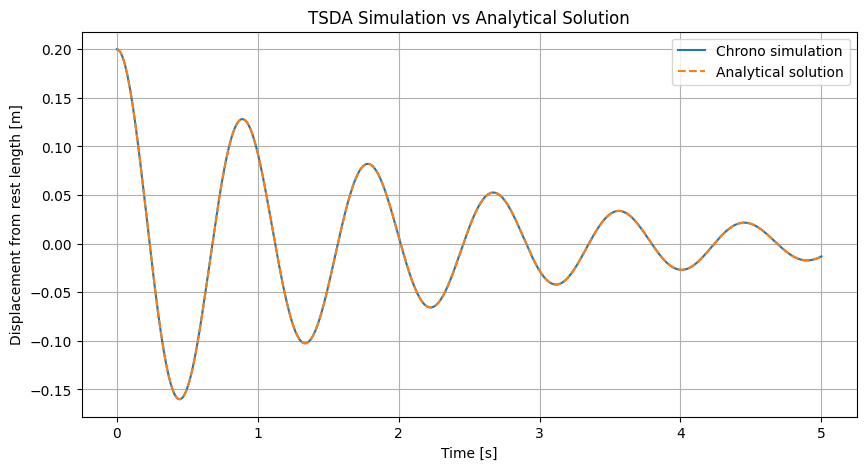

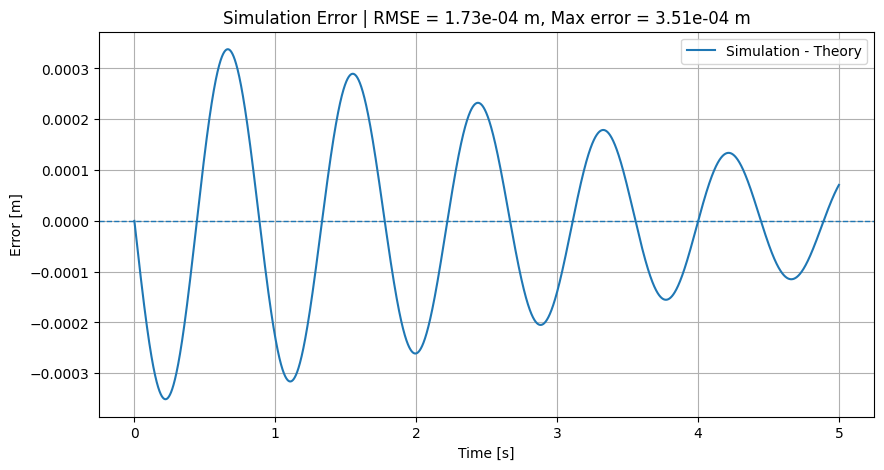

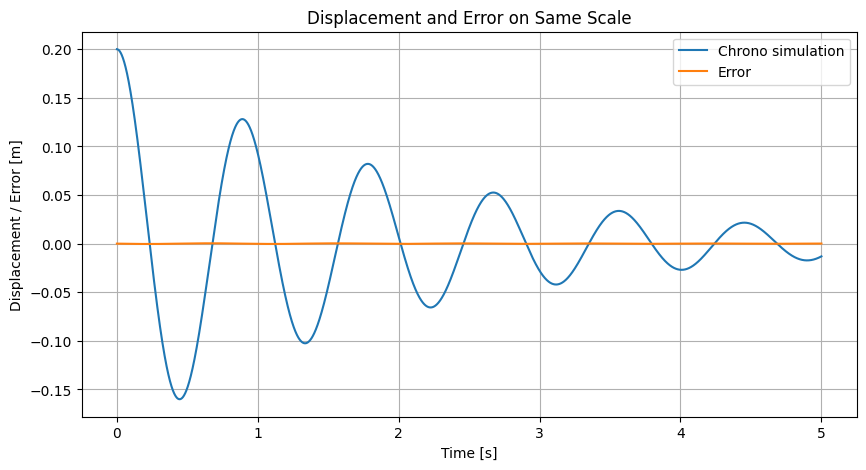

In [15]:
# =============================================================================
# Example 5. TSDA simulation vs analytical solution - improved version
# =============================================================================

# =============================================================================
# Simulation parameters
# =============================================================================

mass = 1.0
k = 50.0
c = 1.0
rest_length = 1.0

x0 = 0.2      # initial displacement from rest length [m]
v0 = 0.0      # initial velocity [m/s]

initial_position = rest_length + x0

# dt를 줄이면 Chrono 수치적분 오차가 더 작아진다.
dt = 0.0005
t_end = 5.0


# =============================================================================
# Create Chrono system
# =============================================================================

system = chrono.ChSystemNSC()
system.SetGravitationalAcceleration(chrono.ChVector3d(0, 0, 0))


# =============================================================================
# Ground body
# =============================================================================

ground = chrono.ChBody()
ground.SetFixed(True)
ground.SetPos(chrono.ChVector3d(0, 0, 0))
system.Add(ground)


# =============================================================================
# Moving body
# =============================================================================

body = chrono.ChBody()
body.SetMass(mass)
body.SetInertiaXX(chrono.ChVector3d(1, 1, 1))
body.SetPos(chrono.ChVector3d(initial_position, 0, 0))
body.SetLinVel(chrono.ChVector3d(v0, 0, 0))
system.Add(body)


# =============================================================================
# TSDA
# =============================================================================

spring = chrono.ChLinkTSDA()

# local=False 이므로 두 점은 절대좌표계 기준이다.
# 초기 TSDA 길이가 rest_length + x0가 되도록 body 쪽 연결점을 초기 body 위치에 둔다.
point_ground_abs = chrono.ChVector3d(0, 0, 0)
point_body_abs = chrono.ChVector3d(initial_position, 0, 0)

spring.Initialize(
    ground,
    body,
    False,
    point_ground_abs,
    point_body_abs
)

spring.SetRestLength(rest_length)
spring.SetSpringCoefficient(k)
spring.SetDampingCoefficient(c)

system.AddLink(spring)


# =============================================================================
# Data storage
# =============================================================================

time_data = []
sim_data = []
length_data = []


# =============================================================================
# Record initial condition before stepping
# =============================================================================

time_data.append(system.GetChTime())
length_data.append(spring.GetLength())
sim_data.append(spring.GetLength() - rest_length)


# =============================================================================
# Simulation loop
# =============================================================================

while system.GetChTime() < t_end:
    system.DoStepDynamics(dt)

    time = system.GetChTime()
    length = spring.GetLength()
    x = length - rest_length

    time_data.append(time)
    length_data.append(length)
    sim_data.append(x)


time_data = np.array(time_data)
sim_data = np.array(sim_data)
length_data = np.array(length_data)


# =============================================================================
# Analytical solution
# =============================================================================

omega_n = np.sqrt(k / mass)
zeta = c / (2 * np.sqrt(mass * k))

if zeta < 1:
    omega_d = omega_n * np.sqrt(1 - zeta**2)

    theory_data = np.exp(-zeta * omega_n * time_data) * (
        x0 * np.cos(omega_d * time_data)
        + ((v0 + zeta * omega_n * x0) / omega_d) * np.sin(omega_d * time_data)
    )

else:
    raise ValueError("This analytical solution assumes an underdamped system: zeta < 1")


# =============================================================================
# Error metrics
# =============================================================================

error = sim_data - theory_data

rmse = np.sqrt(np.mean(error ** 2))
max_error = np.max(np.abs(error))
relative_max_error = max_error / abs(x0) * 100


print(f"Natural frequency omega_n      = {omega_n:.6f} rad/s")
print(f"Damping ratio zeta             = {zeta:.6f}")
print(f"Damped natural frequency omega_d = {omega_d:.6f} rad/s")
print(f"RMSE                           = {rmse:.10f} m")
print(f"Max error                      = {max_error:.10f} m")
print(f"Relative max error             = {relative_max_error:.6f} %")


# =============================================================================
# Plot 1. Simulation vs analytical solution
# =============================================================================

plt.figure(figsize=(10, 5))
plt.plot(time_data, sim_data, label="Chrono simulation")
plt.plot(time_data, theory_data, "--", label="Analytical solution")
plt.xlabel("Time [s]")
plt.ylabel("Displacement from rest length [m]")
plt.title("TSDA Simulation vs Analytical Solution")
plt.grid(True)
plt.legend()
plt.show()


# =============================================================================
# Plot 2. Error
# =============================================================================

plt.figure(figsize=(10, 5))
plt.plot(time_data, error, label="Simulation - Theory")
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Time [s]")
plt.ylabel("Error [m]")
plt.title(
    f"Simulation Error | RMSE = {rmse:.2e} m, Max error = {max_error:.2e} m"
)
plt.grid(True)
plt.legend()
plt.show()


# =============================================================================
# Plot 3. Error compared with displacement scale
# =============================================================================

plt.figure(figsize=(10, 5))
plt.plot(time_data, sim_data, label="Chrono simulation")
plt.plot(time_data, error, label="Error")
plt.xlabel("Time [s]")
plt.ylabel("Displacement / Error [m]")
plt.title("Displacement and Error on Same Scale")
plt.grid(True)
plt.legend()
plt.show()

## Example 5 해석

RMSE가 작으면 Chrono 시뮬레이션과 이론해가 잘 일치한다는 뜻이다.

오차가 커지는 대표적인 원인은 다음과 같다.

```text
1. dt가 너무 큼
2. 초기 위치 또는 초기 속도가 이론해와 다름
3. rest_length 기준이 잘못됨
4. 힘의 부호가 반대로 설정됨
5. Chrono에서 측정한 변위와 이론해의 변위 기준이 다름
6. 감쇠비 공식 또는 고유진동수 계산이 잘못됨
```

이 예제에서는 `x = body.GetPos().x - rest_length`를 변위로 사용했기 때문에, 이론해의 `x(t)`와 같은 기준으로 비교할 수 있다.


---  

# 마무리 정리

이 노트북에서 확인한 핵심 내용은 다음과 같다.

```text
1. TSDA는 병진 방향 스프링-댐퍼이다.
2. RSDA는 회전 방향 스프링-댐퍼이다.
3. ForceFunctor를 사용하면 사용자가 직접 힘 모델을 정의할 수 있다.
4. TorqueFunctor를 사용하면 사용자가 직접 토크 모델을 정의할 수 있다.
5. 이론해와 비교하면 Chrono 모델이 올바른지 검증할 수 있다.
6. RMSE는 시뮬레이션과 이론해의 차이를 정량적으로 평가하는 지표이다.
```

